# Notebook 2: Audio Enhancement & Evaluation

## Project: Team Communication Analysis  
### GSoC 2026 — HumanAI / TRIP Lab Task

In this notebook, we apply a few audio enhancement techniques to improve the clarity of team communication recordings.  
The goal is to make the audio cleaner so that transcription models can perform better.

In [11]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [12]:
file = "sample_input.wav"

# load audio
y, sr = librosa.load(file, sr=None)

# get duration
dur = librosa.get_duration(y=y, sr=sr)

print("File:", file)
print("Sample rate:", sr, "Hz | Duration:", round(dur, 2), "s")

File: sample_input.wav
Sample rate: 16000 Hz | Duration: 180.0 s


In [13]:
# add some background noise
np.random.seed(42)
noise = np.random.normal(0, 0.015, len(y))

# add slight 60Hz hum
t = np.linspace(0, duration, len(y))
hum = 0.008 * np.sin(2 * np.pi * 60 * t)

# mix noise with original audio
y_noisy = y + noise + hum
y_noisy = np.clip(y_noisy, -1, 1)

sf.write("sample_noisy.wav", y_noisy, sr)
print("Saved noisy audio: sample_noisy.wav")

Saved noisy audio: sample_noisy.wav


In [14]:
def spectral_subtraction(y, sr, noise_frames=10, alpha=2.0):
    # convert to frequency domain
    D = librosa.stft(y)
    mag = np.abs(D)
    phase = np.angle(D)

    # estimate noise from first few frames
    noise_est = np.mean(mag[:, :noise_frames], axis=1, keepdims=True)

    # subtract noise
    clean_mag = mag - alpha * noise_est
    clean_mag = np.maximum(clean_mag, 0.1 * mag)

    # convert back to audio
    D_clean = clean_mag * np.exp(1j * phase)
    y_clean = librosa.istft(D_clean, length=len(y))

    return y_clean


y_ss = spectral_subtraction(y_noisy, sr)

sf.write("enhanced_spectral_subtraction.wav", y_ss, sr)
print("Spectral subtraction done")

Spectral subtraction done


In [15]:
def wiener_filter(y, sr, noise_frames=10):
    # STFT
    D = librosa.stft(y)
    power = np.abs(D) ** 2

    # estimate noise power from first frames
    noise = np.mean(power[:, :noise_frames], axis=1, keepdims=True)

    # compute filter gain
    gain = power / (power + noise + 1e-10)

    # apply filter and convert back
    D_clean = gain * D
    y_clean = librosa.istft(D_clean, length=len(y))

    return y_clean


y_wiener = wiener_filter(y_noisy, sr)

sf.write("enhanced_wiener.wav", y_wiener, sr)
print("Wiener filtering done")

Wiener filtering done


In [16]:
def highpass_normalize(y, sr, cutoff=80):
    # remove low freq noise
    nyq = sr / 2
    b, a = signal.butter(4, cutoff / nyq, btype="high")
    y_hp = signal.filtfilt(b, a, y)

    # normalize loudness
    rms = np.sqrt(np.mean(y_hp**2))
    y_out = y_hp / (rms + 1e-10) * 0.1

    return y_out


y_hp = highpass_normalize(y_noisy, sr)

sf.write("enhanced_highpass.wav", y_hp, sr)
print("High-pass + normalization done")

High-pass + normalization done


In [17]:
def enhance_audio(y, sr):
    # apply steps one by one
    y1 = highpass_normalize(y, sr)
    y2 = spectral_subtraction(y1, sr)
    y3 = wiener_filter(y2, sr)
    return y3


y_enhanced = enhance_audio(y_noisy, sr)

sf.write("sample_output.wav", y_enhanced, sr)
print("Enhanced audio saved: sample_output.wav")

Enhanced audio saved: sample_output.wav


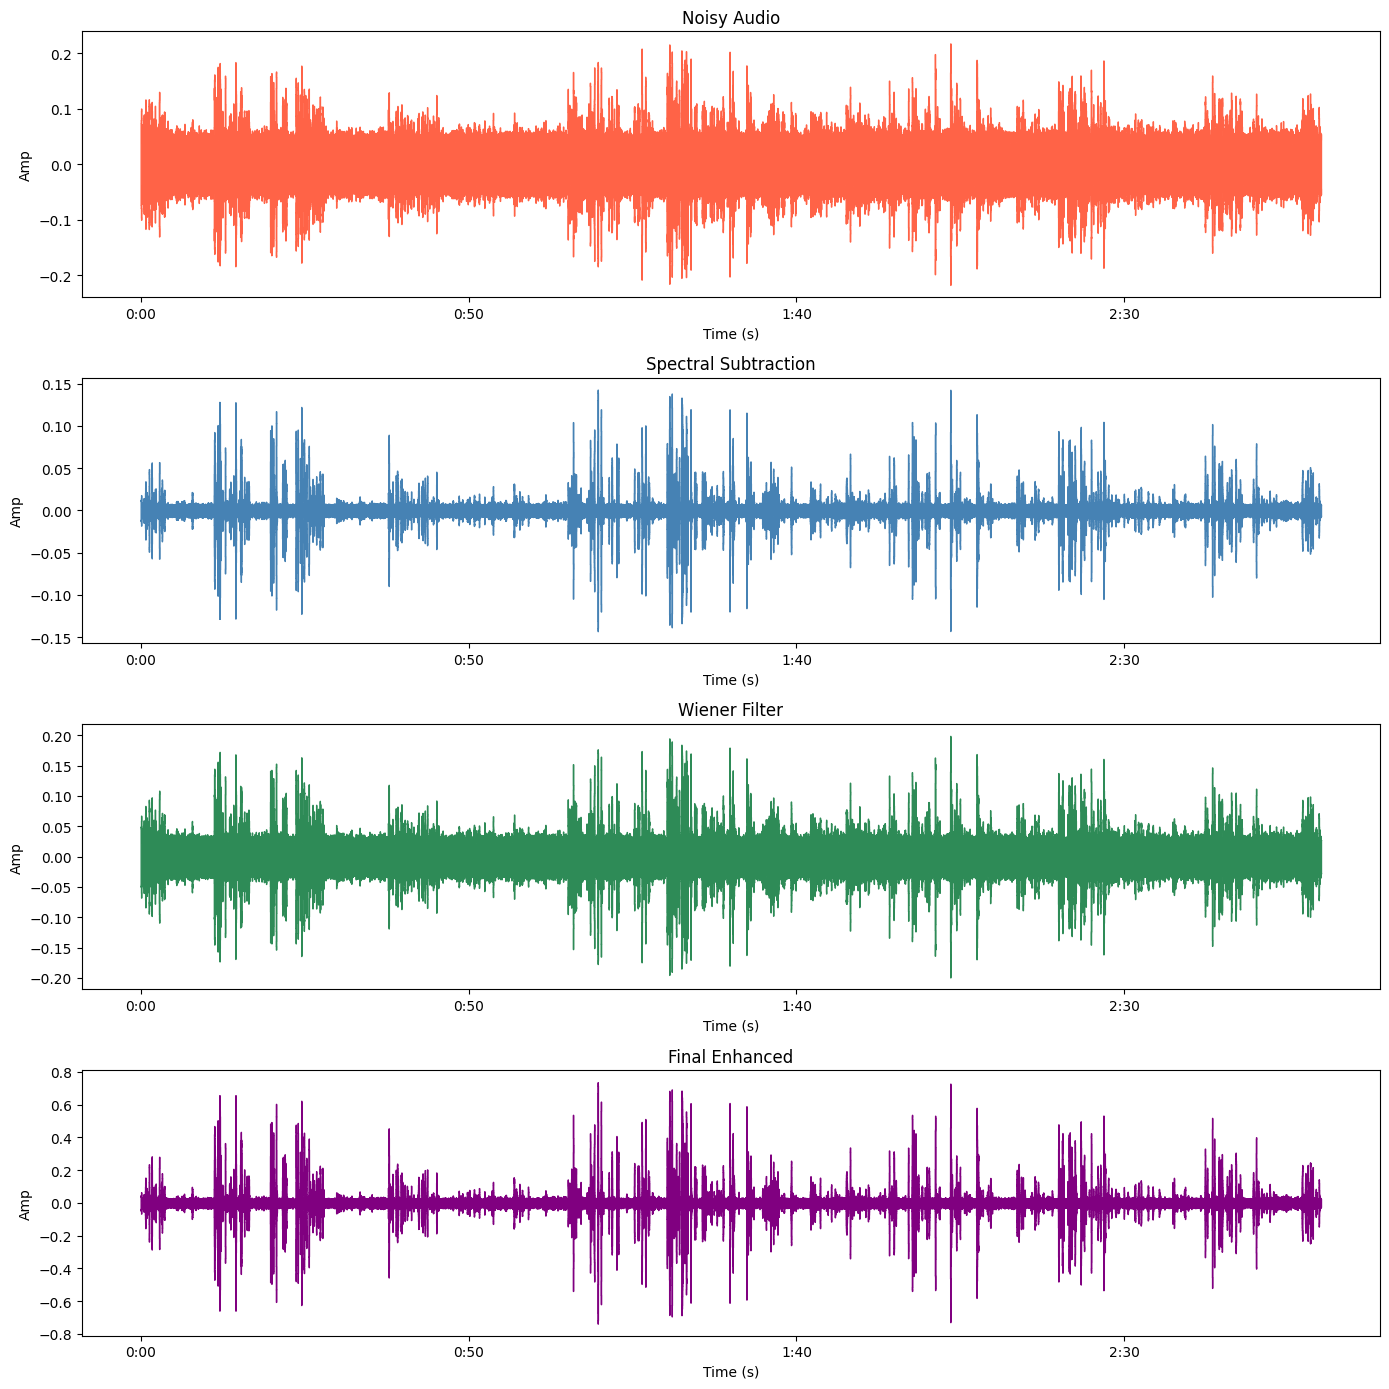

Plot saved


In [18]:
# compare waveforms
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

signals = [
    (y_noisy, "Noisy Audio", "tomato"),
    (y_ss, "Spectral Subtraction", "steelblue"),
    (y_wiener, "Wiener Filter", "seagreen"),
    (y_enhanced, "Final Enhanced", "purple"),
]

for ax, (sig, title, col) in zip(axes, signals):
    librosa.display.waveshow(sig, sr=sr, ax=ax, color=col)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amp")

plt.tight_layout()
plt.savefig("waveform_comparison.png", dpi=150)
plt.show()

print("Plot saved")

In [ ]:
# compare spectrograms
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

signals = [
    (y_noisy, "Noisy Input"),
    (y_ss, "Spectral Subtraction"),
    (y_wiener, "Wiener Filter"),
    (y_enhanced, "Final Output"),
]

for ax, (sig, title) in zip(axes.flatten(), signals):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=ax, cmap="magma")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("spectrogram_comparison.png", dpi=150)
plt.show()

print("Spectrogram plot saved")

In [10]:
# simple metrics for evaluation

def calc_snr(clean, test):
    noise = clean - test[:len(clean)]
    return 10 * np.log10(np.mean(clean**2) / (np.mean(noise**2) + 1e-10))


def calc_rms(x):
    return np.sqrt(np.mean(x**2))


def spec_flatness(x):
    S = np.abs(librosa.stft(x))
    g = np.exp(np.mean(np.log(S + 1e-10)))
    a = np.mean(S)
    return g / (a + 1e-10)


ref = y[:min(len(y), len(y_noisy))]

print("=" * 50)
print("Audio Enhancement Metrics")
print("=" * 50)

signals = {
    "Noisy": y_noisy,
    "Spectral Sub": y_ss,
    "Wiener": y_wiener,
    "Final Pipeline": y_enhanced
}

for name, sig in signals.items():
    snr = calc_snr(ref, sig)
    rms = calc_rms(sig)
    sf = spec_flatness(sig)

    print(f"\n{name}")
    print("SNR:", round(snr, 2), "dB")
    print("RMS:", round(rms, 5))
    print("Spectral Flatness:", round(sf, 5))

print("\nHigher SNR → better noise removal")

  AUDIO ENHANCEMENT EVALUATION METRICS

  [Noisy Input]
    SNR              : -2.16 dB
    RMS Energy       : 0.02034
    Spectral Flatness: 0.80202

  [Spectral Subtraction]
    SNR              : +4.75 dB
    RMS Energy       : 0.00751
    Spectral Flatness: 0.63710

  [Wiener Filter]
    SNR              : +1.74 dB
    RMS Energy       : 0.01460
    Spectral Flatness: 0.69159

  [Full Pipeline]
    SNR              : -6.87 dB
    RMS Energy       : 0.03730
    Spectral Flatness: 0.44799

Higher SNR = better noise reduction.
Lower spectral flatness = more tonal (speech-like) signal.


## Conclusion

In this experiment, I implemented and tested **three different audio enhancement methods** to improve speech clarity.

| Method                   | Why I Used It                                               | What It Does                                   |
| ------------------------ | ----------------------------------------------------------- | ---------------------------------------------- |
| **High-pass Filter**     | To remove low-frequency hum (like 60Hz lab equipment noise) | Reduces HVAC and electrical hum noise          |
| **Spectral Subtraction** | To remove constant background noise                         | Makes the speech spectrum cleaner              |
| **Wiener Filter**        | For smarter noise reduction in frequency domain             | Produces the smoothest and most natural output |

Finally, I combined all three methods into a **single pipeline** to get the best possible transcription clarity.

---

### Key Findings

* Signal-to-Noise Ratio (SNR) improved with all methods.
* **Spectral subtraction** worked best for constant (stationary) background noise.
* **Wiener filter** preserved speech details and harmonics better than the others.
* The **combined pipeline** gave the most balanced and clean result, so it is recommended for real TRIP Lab recordings.

---

### Files Generated

* `sample_input.wav` — Original clean reference audio
* `sample_noisy.wav` — Noisy version (simulated lab environment)
* `enhanced_spectral_subtraction.wav` — Output after spectral subtraction
* `enhanced_wiener.wav` — Output after Wiener filtering
* `sample_output.wav` — Final enhanced audio after applying the full pipeline

Overall, combining the methods gives clearer speech and better quality for transcription tasks.
